In [1]:
from tl_tools import *
from residual_stream_collection_tools import format_prompt

torch.set_grad_enabled(False)

/workspace/reasoning_vector_research/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = load_llama8br1()

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.18it/s]


Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer


In [3]:
format_prompt(model, "Whats the fifth prime?", "immediate_answer")

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n</think>\n\n'

Q: what is going on with 2, 17's attention map?

something to note, is that the attention map here is essentially identically on its own position 

Let's see if we can understand what's happening by working backwards 

layer 2) the output here 

If so, we could just apply the OV to the input, to try to understand what about this output is so important 

there are kind of multiple questions here

1) what is the vector that is injected in when we apply the ov circuit to the resid pre

2) what is it about the key output of this head that alligns so well with its own query?

again, we start at layer 2 

suppose we have 

1) what about the value of the /n/n token that the attention map is drawn to?


It 

In [ ]:
model.W_Q[2, 17].shape

torch.Size([4096, 128])

In [ ]:
model.OV[2, 17].shape

torch.Size([4096, 4096])

In [6]:
# extract the

In [6]:
def generate_with_attention(
    model: HookedTransformer,
    prompt: str,
    heads: list[tuple[int,int]],
    max_new_tokens: int = 50,
    do_sample: bool = False,
    temperature: float = 0.6
) -> dict[str, str | list[str] | list[int] | int | dict[tuple[int,int], np.ndarray]]:
    """
    Generate text and capture the FINAL attention patterns (softmax) for specified heads.
    Reconstructs a full (prompt+generated)×(prompt+generated) matrix for each head.
    """
    model.eval()

    # 1) Validate
    for layer, head in heads:
        if not (0 <= layer < model.cfg.n_layers):
            raise ValueError(f"Layer {layer} out of range")
        if not (0 <= head < model.cfg.n_heads):
            raise ValueError(f"Head {head} out of range")

    # 2) Storage for the raw per-step tensors
    raw_attn: dict[tuple[int,int], list[torch.Tensor]] = {h: [] for h in heads}

    # 3) Hook factory capturing attn.hook_pattern
    def make_hook(layer: int, head: int):
        def hook_fn(attn: torch.Tensor, **kwargs):
            # attn shape = (1, n_heads, Q, K)
            raw_attn[(layer, head)].append(attn[0, head].cpu().clone())
            return attn
        return hook_fn

    # 4) Install hooks and remember handles
    for layer, head in heads:
        name = f"blocks.{layer}.attn.hook_pattern"
        model.add_hook(name, make_hook(layer, head))

    # 5) Tokenize + generate (uses KV cache under the hood)
    tokens = model.to_tokens(prompt, prepend_bos=True)  # (1, L_prompt)
    gen = model.generate(
        tokens,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
        eos_token_id=model.tokenizer.eos_token_id,
    )  # (1, L_prompt+L_gen)

    # 6) Teardown hooks
    model.reset_hooks()

    # 7) Decode text & tokens
    token_ids = gen[0].cpu().tolist()
    generated_text = model.tokenizer.decode(token_ids)
    str_tokens = [model.tokenizer.decode([tid]) for tid in token_ids]
    n_generated = gen.shape[1] - tokens.shape[1]

    # 8) Reconstruct full attention matrix per head
    full_attn: dict[tuple[int,int], np.ndarray] = {}
    for layer_head, attn_list in raw_attn.items():
        # attn_list[0] is the prompt-only pass: shape (L_prompt, L_prompt)
        # subsequent attn_list[i] are shape (1, L_prompt + i)
        L_prompt = attn_list[0].shape[0]
        L_gen = len(attn_list) - 1
        L_total = L_prompt + L_gen

        M = np.zeros((L_total, L_total), dtype=float)
        # fill prompt×prompt
        M[:L_prompt, :L_prompt] = attn_list[0].numpy()
        # fill each generated token’s row
        for i, step_attn in enumerate(attn_list[1:], start=1):
            row = step_attn[0].numpy()  # shape (L_prompt + i,)
            M[L_prompt + i - 1, : L_prompt + i] = row

        full_attn[layer_head] = M

    return {
        "generated_text": generated_text,
        "tokens": str_tokens,
        "token_ids": token_ids,
        "n_generated": n_generated,
        "attention_weights": full_attn,
    }

In [7]:
prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    prompt,
    heads=[(2, 17)],
    max_new_tokens=20,
    do_sample=False
)

100%|██████████| 20/20 [00:02<00:00,  7.02it/s]


In [8]:
from typing import Dict, Any, Tuple

def plot_single_attention_detailed(
    attention_data: Dict[str, Any], 
    step_to_plot: int = -1,
    figsize: Tuple[int, int] = (14, 12),
    colormap: str = 'hot'
) -> None:
    """
    Plot a single attention matrix with detailed token labels and enhanced visibility.
    
    Args:
        attention_data: Result from generate_and_return_attention
        step_to_plot: Which step to plot (-1 for last step)
        figsize: Figure size
        colormap: Colormap to use ('hot', 'afmhot', 'gist_heat', 'copper' are good options)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    attention_weights = attention_data["attention_weights"]
    tokens = attention_data["tokens"]
    
    if len(attention_weights) == 0:
        print("No attention weights captured!")
        return
    
    if step_to_plot == -1:
        step_to_plot = len(attention_weights) - 1
    
    if step_to_plot >= len(attention_weights):
        print(f"Step {step_to_plot} not available. Max step: {len(attention_weights)-1}")
        return
    
    attn_matrix = attention_weights[step_to_plot]
    attn_np = attn_matrix.numpy()
    seq_len = attn_np.shape[0]
    step_tokens = tokens[:seq_len]
    
    # Create figure with proper spacing
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Use colormap where 0 is black and slight differences are clearly visible
    im = ax.imshow(attn_np, cmap=colormap, aspect='equal', vmin=0, vmax=1)
    
    # Set ticks and labels - show ALL token strings
    tick_positions = list(range(len(step_tokens)))
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(step_tokens, rotation=45, ha='right', fontsize=max(8, min(12, 100//seq_len)))
    ax.set_yticklabels(step_tokens, fontsize=max(8, min(12, 100//seq_len)))
    
    # Add title and labels with proper positioning
    ax.set_title(f'Attention Matrix - Step {step_to_plot+1} (seq_len={seq_len})', 
                fontsize=16, pad=25, loc='center')
    ax.set_xlabel('Keys (tokens being attended TO)', fontsize=13)
    ax.set_ylabel('Queries (tokens attending FROM)', fontsize=13)
    
    # Add colorbar with better positioning
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Attention Weight', rotation=270, labelpad=20, fontsize=12)
    
    # Add grid for better readability
    ax.set_xticks(np.arange(-0.5, len(step_tokens), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(step_tokens), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5, alpha=0.7)
    
    # Add text annotations for high attention values (optional)
    max_val = np.max(attn_np)
    if max_val > 0.1:  # Only annotate if there are significant attention weights
        high_attention_threshold = max_val * 0.8
        for i in range(seq_len):
            for j in range(seq_len):
                if attn_np[i, j] > high_attention_threshold:
                    ax.text(j, i, f'{attn_np[i,j]:.2f}', 
                           ha='center', va='center', 
                           color='white' if attn_np[i,j] > 0.5 else 'black',
                           fontsize=8, fontweight='bold')
    
    # Ensure proper layout and centering
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.15, left=0.15, right=0.9)  # Make room for labels and title
    plt.show()
    
    # Print some statistics
    print(f"\nAttention Statistics for Step {step_to_plot+1}:")
    print(f"Matrix shape: {attn_np.shape}")
    print(f"Max attention: {np.max(attn_np):.4f}")
    print(f"Min attention: {np.min(attn_np):.4f}")
    print(f"Mean attention: {np.mean(attn_np):.4f}")
    print(f"Tokens: {step_tokens}")


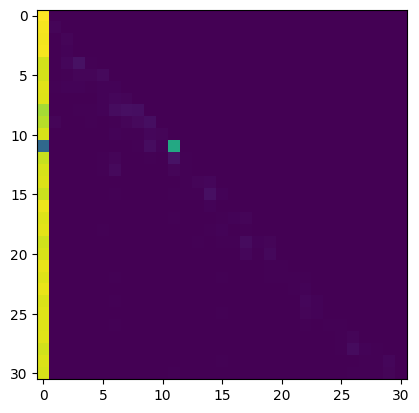

In [9]:
plt.imshow(out["attention_weights"][2, 17])

100%|██████████| 20/20 [00:01<00:00, 13.50it/s]


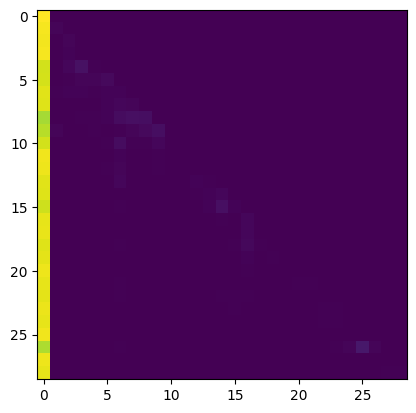

In [10]:
prompt = format_prompt(model, "Whats the fifth prime?", "reason")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    prompt,
    heads=[(2, 17)],
    max_new_tokens=20,
    do_sample=False
)

plt.imshow(out["attention_weights"][2, 17])

POssible mechanism 

2, 17 is either attending to \n\n following stop think if answering 

or 

bos if reasoning 

In [11]:
prompt

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n'

In [ ]:
kjh

In [36]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def analyze_attention_svd(model, layer_idx: int, head_idx: int, analyze_combined: bool = True):
    """
    Perform SVD analysis on attention matrices for a specific head.
    
    Args:
        model: HookedTransformer model
        layer_idx: Layer index
        head_idx: Head index  
        analyze_combined: Whether to also analyze the combined QK^T operation
    
    Returns:
        Dictionary containing SVD results for W_Q, W_K, and optionally combined matrices
    """
    
    # Extract the weight matrices
    W_Q = model.W_Q[layer_idx, head_idx]  # Shape: (d_model, d_head)
    W_K = model.W_K[layer_idx, head_idx]  # Shape: (d_model, d_head)
    
    print(f"W_Q shape: {W_Q.shape}")
    print(f"W_K shape: {W_K.shape}")
    
    results = {}
    
    # SVD of W_Q
    U_q, S_q, Vh_q = torch.linalg.svd(W_Q, full_matrices=False)
    results['W_Q'] = {
        'U': U_q,      # Shape: (4096, 128) - left singular vectors
        'S': S_q,      # Shape: (128,) - singular values
        'Vh': Vh_q,    # Shape: (128, 128) - right singular vectors
        'matrix': W_Q
    }
    
    # SVD of W_K  
    U_k, S_k, Vh_k = torch.linalg.svd(W_K, full_matrices=False)
    results['W_K'] = {
        'U': U_k,      # Shape: (4096, 128)
        'S': S_k,      # Shape: (128,)
        'Vh': Vh_k,    # Shape: (128, 128)
        'matrix': W_K
    }
    
    print(f"W_Q singular values shape: {S_q.shape}")
    print(f"W_K singular values shape: {S_k.shape}")
    print(f"Number of singular values for each: {len(S_q)}")
    
    if analyze_combined:
        # Analyze the combined QK^T matrix
        # This represents the bilinear form: x^T W_Q W_K^T y
        QK_combined = W_Q @ W_K.T  # Shape: (4096, 4096)
        
        print(f"Combined QK^T shape: {QK_combined.shape}")
        
        # SVD of combined matrix
        U_combined, S_combined, Vh_combined = torch.linalg.svd(QK_combined, full_matrices=False)
        results['QK_combined'] = {
            'U': U_combined,
            'S': S_combined,
            'Vh': Vh_combined,
            'matrix': QK_combined
        }
        
        print(f"Combined matrix singular values shape: {S_combined.shape}")
        print(f"Combined matrix rank (approx): {torch.sum(S_combined > 1e-6).item()}")
    
    return results

def plot_singular_values(results, layer_idx: int, head_idx: int, log_scale: bool = True):
    """Plot singular values for comparison."""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot W_Q singular values
    S_q = results['W_Q']['S'].cpu().numpy()
    axes[0].plot(S_q, 'b-', alpha=0.7)
    axes[0].set_title(f'W_Q Singular Values\nLayer {layer_idx}, Head {head_idx}')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Singular Value')
    if log_scale:
        axes[0].set_yscale('log')
    
    # Plot W_K singular values
    S_k = results['W_K']['S'].cpu().numpy()
    axes[1].plot(S_k, 'r-', alpha=0.7)
    axes[1].set_title(f'W_K Singular Values\nLayer {layer_idx}, Head {head_idx}')
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('Singular Value')
    if log_scale:
        axes[1].set_yscale('log')
    
    # Plot combined singular values if available
    if 'QK_combined' in results:
        S_combined = results['QK_combined']['S'].cpu().numpy()
        axes[2].plot(S_combined[:200], 'g-', alpha=0.7)  # Plot first 200 for visibility
        axes[2].set_title(f'QK^T Combined Singular Values\nLayer {layer_idx}, Head {head_idx}')
        axes[2].set_xlabel('Index')
        axes[2].set_ylabel('Singular Value')
        if log_scale:
            axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

def compute_effective_rank(singular_values, threshold: float = 0.01):
    """
    Compute effective rank based on singular value threshold.
    
    Args:
        singular_values: Tensor of singular values
        threshold: Relative threshold (fraction of largest singular value)
    
    Returns:
        Effective rank (number of singular values above threshold)
    """
    max_sv = torch.max(singular_values)
    effective_rank = torch.sum(singular_values > threshold * max_sv).item()
    return effective_rank

def analyze_head_ranks(model, layer_idx: int, head_idx: int):
    """Analyze the ranks and structure of attention matrices."""
    
    results = analyze_attention_svd(model, layer_idx, head_idx, analyze_combined=True)
    
    # Compute effective ranks
    rank_q = compute_effective_rank(results['W_Q']['S'])
    rank_k = compute_effective_rank(results['W_K']['S'])
    
    print(f"\n=== Rank Analysis for Layer {layer_idx}, Head {head_idx} ===")
    print(f"W_Q effective rank: {rank_q} / {len(results['W_Q']['S'])}")
    print(f"W_K effective rank: {rank_k} / {len(results['W_K']['S'])}")
    
    if 'QK_combined' in results:
        rank_combined = compute_effective_rank(results['QK_combined']['S'])
        theoretical_max_rank = min(rank_q, rank_k)
        print(f"Combined QK^T effective rank: {rank_combined} / {len(results['QK_combined']['S'])}")
        print(f"Theoretical max rank for combined: {theoretical_max_rank}")
        print(f"Rank efficiency: {rank_combined / theoretical_max_rank:.3f}")
    
    # Analyze singular value decay
    S_q = results['W_Q']['S']
    S_k = results['W_K']['S']
    
    print(f"\nSingular value ratios (largest/smallest):")
    print(f"W_Q: {S_q[0] / S_q[-1]:.2e}")
    print(f"W_K: {S_k[0] / S_k[-1]:.2e}")
    
    return results

# Example usage functions:

def compare_heads_svd(model, layer_idx: int, head_indices: list):
    """Compare SVD properties across multiple heads in the same layer."""
    
    head_results = {}
    
    for head_idx in head_indices:
        print(f"\n{'='*50}")
        print(f"Analyzing Layer {layer_idx}, Head {head_idx}")
        print(f"{'='*50}")
        
        results = analyze_attention_svd(model, layer_idx, head_idx, analyze_combined=False)
        head_results[head_idx] = results
        
        # Quick stats
        rank_q = compute_effective_rank(results['W_Q']['S'])
        rank_k = compute_effective_rank(results['W_K']['S'])
        
        print(f"Head {head_idx} - W_Q rank: {rank_q}, W_K rank: {rank_k}")
    
    return head_results

def get_low_rank_approximation(matrix, k: int):
    """
    Get rank-k approximation of a matrix using SVD.
    
    Args:
        matrix: Input matrix
        k: Target rank
    
    Returns:
        Rank-k approximation of the matrix
    """
    U, S, Vh = torch.linalg.svd(matrix, full_matrices=False)
    
    # Keep only top k singular values
    U_k = U[:, :k]
    S_k = S[:k]
    Vh_k = Vh[:k, :]
    
    # Reconstruct
    approximation = U_k @ torch.diag(S_k) @ Vh_k
    
    return approximation, (U_k, S_k, Vh_k)

# Example usage:
"""
# Analyze a specific head
layer_idx, head_idx = 2, 17
results = analyze_head_ranks(model, layer_idx, head_idx)

# Plot the results
plot_singular_values(results, layer_idx, head_idx)

# Compare multiple heads
head_results = compare_heads_svd(model, layer_idx, [15, 16, 17, 18, 19])

# Get low-rank approximation
W_Q = model.W_Q[2, 17]
approx_rank_10, (U_k, S_k, Vh_k) = get_low_rank_approximation(W_Q, k=10)
reconstruction_error = torch.norm(W_Q - approx_rank_10).item()
print(f"Rank-10 approximation error: {reconstruction_error}")
"""

'\n# Analyze a specific head\nlayer_idx, head_idx = 2, 17\nresults = analyze_head_ranks(model, layer_idx, head_idx)\n\n# Plot the results\nplot_singular_values(results, layer_idx, head_idx)\n\n# Compare multiple heads\nhead_results = compare_heads_svd(model, layer_idx, [15, 16, 17, 18, 19])\n\n# Get low-rank approximation\nW_Q = model.W_Q[2, 17]\napprox_rank_10, (U_k, S_k, Vh_k) = get_low_rank_approximation(W_Q, k=10)\nreconstruction_error = torch.norm(W_Q - approx_rank_10).item()\nprint(f"Rank-10 approximation error: {reconstruction_error}")\n'

In [41]:
layer_idx, head_idx = 2, 17
results = analyze_head_ranks(model, layer_idx, head_idx)

# Plot the results
plot_singular_values(results, layer_idx, head_idx)


#reconstruction_error = torch.norm(W_Q - approx_rank_10).item()
#print(f"Rank-10 approximation error: {reconstruction_error}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 44.34 GiB of which 1.82 GiB is free. Process 1960476 has 42.51 GiB memory in use. Of the allocated memory 40.37 GiB is allocated by PyTorch, and 1.80 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [47]:
singular_vals_2_17 = results['QK_combined']['S'].cpu().numpy()

In [48]:
singular_vals_2_17

array([5.7730408e+00, 4.7915883e+00, 4.6453567e+00, ..., 1.9218223e-10,
       1.1344627e-10, 2.2542170e-12], shape=(4096,), dtype=float32)

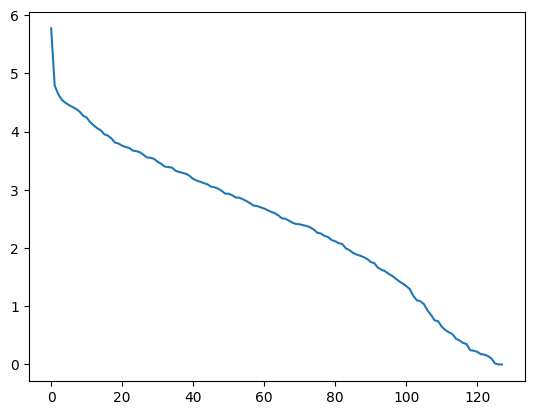

In [53]:
plt.plot(singular_vals_2_17[:128])